### 트랜스포머 구현 코드

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import numpy as np
import pandas as pd
import random
import re
from rdkit import Chem
from collections import defaultdict
import selfies as sf
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset, TensorDataset

In [ ]:
# 학습 데이터셋 불러오기
df = pd.read_csv('/kaggle/input/train-datasets/transformer_train_data.csv')
df.shape

(799120, 3)

In [ ]:
def scaffold_stratified_split(df, scaffold_col='cano_scaffold', val_ratio=0.2, seed=100):
	np.random.seed(seed)

	scaffold_to_indices = defaultdict(list)
	# 형태 : {'scaffold 분자식' : [scaffold의 index]}
	# = scaffold별 인덱스 모으기

	for idx, scaf in enumerate(df[scaffold_col]):
		scaffold_to_indices[scaf].append(idx)

	scaffolds = list(scaffold_to_indices.keys())
	np.random.shuffle(scaffolds)

	train_indices, val_indices = [], []

	# train과 valid 사이에 scaffold 중복이 절대 없게 함
	# = 과적합을 줄이고 학습하지 않은 새로운 분자 예측을 올바르게 수행하기 위해서 
	val_target = int(len(df) * val_ratio) # 약 16만개
	val_count = 0

	for scaf in scaffolds:
		indices = scaffold_to_indices[scaf] # 인덱스 리스트
		if val_count < val_target: # 만약 약 16만개의 valid 데이터셋이 다 채워지지 않았다면
			val_indices.extend(indices) # 해당 scaffold는 전부 validation set
			val_count += len(indices) 
		else:
			train_indices.extend(indices) # 남은건 전부 train dataset

	train_df = df.iloc[train_indices].reset_index(drop=True)
	val_df = df.iloc[val_indices].reset_index(drop=True)
	
	return train_df, val_df

train_df, val_df = scaffold_stratified_split(df, scaffold_col='cano_scaffold', val_ratio=0.2)

In [4]:
train_df.shape, val_df.shape

((639295, 3), (159825, 3))

In [5]:
train_sample = train_df.reset_index()
validation_sample = val_df.reset_index()

In [ ]:
def dataset_encoding(df):
    encodered_list = []
    
    for i in range(len(df['cano_scaffold'])):
        try:
            scaffold_encode = sf.encoder(df['cano_scaffold'].iloc[i])  # scaffold 인코딩
            scaffold_encode_split = list(sf.split_selfies(scaffold_encode))
      
            smiles_encode = sf.encoder(df['cano_smiles'].iloc[i])  # smiles 인코딩
            smiles_encode_split = list(sf.split_selfies(smiles_encode))
            
            encodered_list.append([
                df['cano_scaffold'].iloc[i],
                scaffold_encode_split,
                df['cano_smiles'].iloc[i],
                smiles_encode_split
            ])
        except:
            continue

    return encodered_list

train_encodered_list = dataset_encoding(train_sample)
val_encodered_list = dataset_encoding(validation_sample)

train_x_encoded = [['[SOS]'] + i[1] + ['[EOS]'] for i in train_encodered_list]
train_y_encoded = [['[SOS]'] + i[3] + ['[EOS]'] for i in train_encodered_list]

val_x_encoded = [['[SOS]'] + i[1] + ['[EOS]'] for i in val_encodered_list]
val_y_encoded = [['[SOS]'] + i[3] + ['[EOS]'] for i in val_encodered_list]

# [SOS]와 [EOS]를 붙여서 시작과 끝을 알려줌

In [9]:
len(train_x_encoded), len(train_y_encoded), len(val_x_encoded), len(val_y_encoded)

(636233, 636233, 159825, 159825)

In [ ]:
max_train_x_len = max([len(i) for i in train_x_encoded]) - 2
max_train_y_len = max([len(i) for i in train_y_encoded]) - 2

max_val_x_len = max([len(i) for i in val_x_encoded]) - 2
max_val_y_len = max([len(i) for i in val_y_encoded]) - 2

res_len = max([max_train_x_len, max_train_y_len, max_val_x_len, max_val_y_len])
res_len
# [SOS]와 [EOS]를 제외하고 가장 긴 길이 찾기
# transformer 학습을 위해서 가장 긴 길이로 데이터를 맞춰야 하기 때문

64

In [ ]:
xtrain_encoded2 = [['[SOS]'] + i[1] + ['[EOS]'] + (res_len - len(i[1]))*['[PAD]'] for i in train_encodered_list]
ytrain_encoded2 = [['[SOS]'] + i[3] + ['[EOS]'] + (res_len - len(i[3]))*['[PAD]'] for i in train_encodered_list]

xval_encoded2 = [['[SOS]'] + i[1] + ['[EOS]'] + (res_len - len(i[1]))*['[PAD]'] for i in val_encodered_list]
yval_encoded2 = [['[SOS]'] + i[3] + ['[EOS]'] + (res_len - len(i[3]))*['[PAD]'] for i in val_encodered_list]

# [SOS] + [문자열 인코딩] + [EOS] + ([PAD] * (남은 길이)) 이렇게 해서 총 길이 66으로 맞춤
# train, validation set 모두 해당 과정 수행

In [12]:
np.array(xtrain_encoded2).shape, np.array(ytrain_encoded2).shape

((636233, 66), (636233, 66))

In [13]:
np.array(xval_encoded2).shape, np.array(yval_encoded2).shape

((159825, 66), (159825, 66))

In [ ]:
vocab = []

for i in xtrain_encoded2:
    vocab += i

for j in ytrain_encoded2:
    vocab += j

for k in xval_encoded2:
    vocab += k

for l in yval_encoded2:
    vocab += l

vocab = list(set(vocab)) # [Na], [C]등을 숫자로 인코딩 작업을 위해 여태 나온 모든 원소를 vocab 리스트에 저장
token2id = {tok: i for i, tok in enumerate(vocab)} 
# token2id : {"[B]": 0, "[NH1]": 1, "[#N]": 2, "[N]": 3}

In [ ]:
xtrain = []
ytrain = []
xval = []
yval = []

# 숫자 인코딩 후 리스트에 저장
for x_seq in xtrain_encoded2:
	xtrain.append([token2id[tok] for tok in x_seq])

for y_seq in ytrain_encoded2:
	ytrain.append([token2id[tok] for tok in y_seq])

for x_seq2 in xval_encoded2:
	xval.append([token2id[tok] for tok in x_seq2])

for y_seq2 in yval_encoded2:
	yval.append([token2id[tok] for tok in y_seq2])

xtrain_tensor = torch.tensor(xtrain, dtype=torch.long)
ytrain_tensor = torch.tensor(ytrain, dtype=torch.long)

xval_tensor = torch.tensor(xval, dtype=torch.long)
yval_tensor = torch.tensor(yval, dtype=torch.long)

train_dataset = TensorDataset(xtrain_tensor, ytrain_tensor) # 데이터셋 생성 
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True) # batch_size = 128로 지정

val_dataset = TensorDataset(xval_tensor, yval_tensor)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=True)

In [ ]:
# 모든 입력/출력 토큰 합치기
all_tokens = torch.cat([xtrain_tensor.flatten(), ytrain_tensor.flatten(),
                        xval_tensor.flatten(), yval_tensor.flatten()])

# 각 토큰별 등장 횟수 계산
unique, counts = torch.unique(all_tokens, return_counts=True)
# unique : 0 ~ 71까지 토큰 (72개)
# counts : 각 토큰별 등장 횟수

# token id → 실제 토큰 매핑
id2token = {v: k for k, v in token2id.items()}
# EX) {0: '[S+1]', 1: '[#C-1]', 2: '[#N+1]'}

# 등장 횟수 높은 순 정렬
sorted_counts = sorted(zip(unique.tolist(), counts.tolist()), key=lambda x: x[1], reverse=True)
# EX) (7, 40156239), (63, 21953894),(53, 10431820)

In [ ]:
num_classes = len(token2id) # 72
weights = torch.ones(num_classes)

# 빈도 기반 역비율 가중치
freq = torch.zeros(num_classes)
freq[unique] = counts.float()
weights = 1.0 / (freq + 1e-6) # 분모 0되는 거 방지하려고 1e-6 더함 
weights = weights / weights.sum() * num_classes  
# 가중치의 평균이 1 (가중치가 너무 작아지는 걸 방지하기 위해 정규화 수행)

# PAD는 패딩용 토큰(빈자리 채우기용이라 의미가 없어서 가중치를 0으로)
weights[token2id["[PAD]"]] = 0.0

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, dim_model, dropout_p, max_len=res_len+2):
        super().__init__()
        self.dim_model = dim_model
        self.dropout = nn.Dropout(dropout_p) 
        self.max_len = max_len
        self.register_buffer("pos_encoding", self._build_pos_encoding(max_len, dim_model))
        # pos_encoding이라는 텐서를 객체처럼 등록

    def _build_pos_encoding(self, max_len, dim_model): # (68, 128)
        pos_encoding = torch.zeros(max_len, dim_model) # (68, 128) 형태의 0으로만 구성된 tensor 생성
        positions_list = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # 0 ~ 68까지의 숫자를 넣어놓은 (68, 1) 형태의 tensor
        
        division_term = torch.exp(torch.arange(0, dim_model, 2).float() * (-math.log(10000.0) / dim_model))
        # sin, cos로 위치 인코딩 시 각 위치마다 고유한 값을 반환하게 하기 위해서

        pos_encoding[:, 0::2] = torch.sin(positions_list * division_term)
        pos_encoding[:, 1::2] = torch.cos(positions_list * division_term)
        return pos_encoding.unsqueeze(0) # (1, 68, 128) 형태의 위치 인코딩 반환

    def forward(self, token_embedding: torch.Tensor) -> torch.Tensor:
        seq_len = token_embedding.size(1)
        if seq_len > self.pos_encoding.size(1): # 만약 현재 시퀀스의 길이가 토큰
            self.pos_encoding = self._build_pos_encoding(seq_len, self.dim_model).to(token_embedding.device)
        return self.dropout(token_embedding + self.pos_encoding[:, :seq_len, :])
		# 위치 인코딩 + 토큰 임베딩 값을 더해서 반환함

In [ ]:
class Transformer(nn.Module):
    def __init__(self, num_tokens, dim_model, num_heads,
                 num_encoder_layers, num_decoder_layers, dropout_p):
        super().__init__()

        self.dim_model = dim_model # 128
        self.positional_encoder = PositionalEncoding(
            dim_model=dim_model, # 128
            dropout_p=dropout_p, # 0
            max_len=res_len+2 # 68
        )
        self.embedding = nn.Embedding(num_tokens, dim_model)

        self.transformer = nn.Transformer(
            d_model=dim_model,
            nhead=num_heads,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout_p,
        )
        self.out = nn.Linear(dim_model, num_tokens)

    def forward(self, src, tgt, tgt_mask=None, src_pad_mask=None, tgt_pad_mask=None):
        src = self.embedding(src) * math.sqrt(self.dim_model)
        tgt = self.embedding(tgt) * math.sqrt(self.dim_model)
        src = self.positional_encoder(src)
        tgt = self.positional_encoder(tgt) 

        src = src.permute(1, 0, 2)
        tgt = tgt.permute(1, 0, 2)

        # Transformer
        transformer_out = self.transformer(
            src, tgt,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask
        ) 

        out = self.out(transformer_out).permute(1, 0, 2)
        return out

    def get_tgt_mask(self, size) -> torch.Tensor:
        mask = torch.tril(torch.ones(size, size)).to(torch.bool)
        mask = mask.float()
        mask = mask.masked_fill(mask == 0, float('-inf'))
        mask = mask.masked_fill(mask == 1, float(0.0))
        return mask

    def create_pad_mask(self, matrix: torch.Tensor, pad_token: int) -> torch.Tensor:
        return (matrix == pad_token)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Transformer(num_tokens=len(token2id), dim_model=128, num_heads=4, num_encoder_layers=8, num_decoder_layers=8, dropout_p=0).to(device)
# d_model % nhead == 0은 반드시 맞춰야 함

opt = torch.optim.SGD(model.parameters(), lr=0.05)
weights = weights.to(device) # token별 가중치
loss_fn = nn.CrossEntropyLoss(weights, ignore_index=token2id['[PAD]']) 
# 손실함수에서 [PAD] 토큰은 가중치 0으로 설정

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
def train_loop(model, opt, loss_fn, dataloader, pad_token_id):
    # (model, opt, loss_fn, train_dataloader, token2id['[PAD]'])
    model.train()
    total_loss = 0

    pbar = tqdm(dataloader, desc="Training", leave=False)
    # 모델 학습 진행률 표시
    for X, y in pbar:
        X, y = X.to(device), y.to(device)

        # 디코더 입력과 정답 분리
        y_input = y[:, :-1]
        y_expected = y[:, 1:]

        # 마스크 생성
        seq_len = y_input.size(1)
        tgt_mask = model.get_tgt_mask(seq_len).to(device)
        src_pad_mask = model.create_pad_mask(X, pad_token_id).to(device)
        # 
        tgt_pad_mask = model.create_pad_mask(y_input, pad_token_id).to(device)

        pred = model(
            X, y_input,
            tgt_mask=tgt_mask,
            src_pad_mask=src_pad_mask,
            tgt_pad_mask=tgt_pad_mask
        ) 

        # Loss
        loss = loss_fn(
            pred.reshape(-1, pred.size(-1)),  
            y_expected.reshape(-1)       
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [23]:
def validation_loop(model, loss_fn, dataloader, pad_token_id):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            y_input = y[:, :-1]
            y_expected = y[:, 1:]

            sequence_length = y_input.size(1)
            tgt_mask = model.get_tgt_mask(sequence_length).to(device)
            src_pad_mask = model.create_pad_mask(X, pad_token_id).to(device)
            tgt_pad_mask = model.create_pad_mask(y_input, pad_token_id).to(device)

            pred = model(X, y_input, tgt_mask, src_pad_mask, tgt_pad_mask)

            loss = loss_fn(
                pred.reshape(-1, pred.size(-1)),
                y_expected.reshape(-1)
            )
            total_loss += loss.item()

    return total_loss / len(dataloader)

### 모델 학습 및 Loss 값 저장

In [ ]:
def fit(model, opt, loss_fn, train_dataloader, val_dataloader, epochs):  
    train_loss_list, validation_loss_list = [], []

    print("Training and validating model")
    for epoch in range(epochs):
        print("-"*25, f"Epoch {epoch + 1}","-"*25)

        train_loss = train_loop(model, opt, loss_fn, train_dataloader, token2id['[PAD]'])
        train_loss_list += [train_loss]

        validation_loss = validation_loop(model, loss_fn, val_dataloader,token2id['[PAD]'])
        validation_loss_list += [validation_loss]
        
        print(f"Training loss: {train_loss:.4f}")
        print(f"Validation loss: {validation_loss:.4f}")
        print()

    return train_loss_list, validation_loss_list

train_loss_list,validation_loss_list = fit(model, opt, loss_fn, train_dataloader, val_dataloader, 10)

Training and validating model
------------------------- Epoch 1 -------------------------


Training:   0%|          | 0/4971 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Training loss: 2.3777
Validation loss: 1.8610

------------------------- Epoch 2 -------------------------


Training loss: 1.7431
Validation loss: 1.7072

------------------------- Epoch 3 -------------------------


Training loss: 1.5105
Validation loss: 1.6479

------------------------- Epoch 4 -------------------------


...

Training loss: 1.4608
Validation loss: 1.2661

------------------------- Epoch 7 -------------------------


Training loss: 1.1327
Validation loss: 1.0854

------------------------- Epoch 8 -------------------------


Training loss: 1.0289
Validation loss: 1.0845

------------------------- Epoch 9 -------------------------


Training loss: 1.1149
Validation loss: 1.0616

------------------------- Epoch 10 -------------------------


Training loss: 0.9567
Validation loss: 0.9886



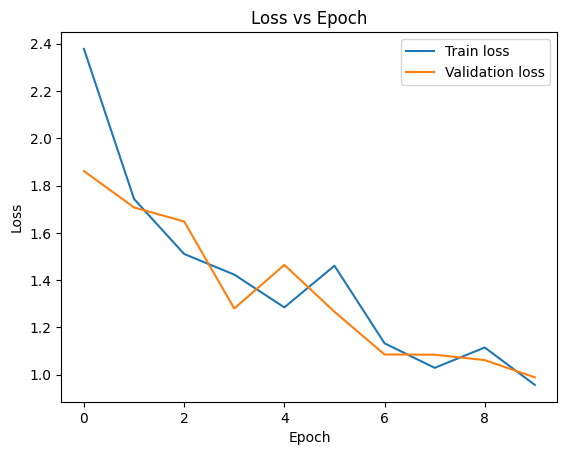

In [25]:
import matplotlib.pyplot as plt

plt.plot(train_loss_list, label = "Train loss")
plt.plot(validation_loss_list, label = "Validation loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

In [34]:
!pip install rdkit

### 예측 수행

In [ ]:
def predict(model, input_sequence, max_length=64, # 예측값 최대 길이는 64로 함
            SOS_token=token2id['[SOS]'], 
            EOS_token=token2id['[EOS]'],
            temperature=1.0):  # temperature 추가
    model.eval()
    
    y_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)
    
    with torch.no_grad():
        for _ in range(max_length):
            tgt_mask = model.get_tgt_mask(y_input.size(1)).to(device)
            pred = model(input_sequence, y_input, tgt_mask)
            
            # Temperature scaling 적용
            logits = pred[0, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            
            # Top-k sampling (다양성 증가)
            top_k = 10
            top_probs, top_indices = torch.topk(probs, top_k)
            top_probs = top_probs / top_probs.sum()
            
            next_item = top_indices[torch.multinomial(top_probs, 1)].item()
            next_item = torch.tensor([[next_item]], device=device)
            
            y_input = torch.cat((y_input, next_item), dim=1)
            
            if next_item.view(-1).item() == EOS_token:
                break
    
    return y_input.view(-1).tolist()


new_scaffold = 'Cn1cnc2c1c(=O)n(c(=O)n2C)C' # 새로운 scaffold 제시
cano_scaffold = Chem.MolToSmiles(Chem.MolFromSmiles(new_scaffold), canonical=True)
# scaffold를 canonical scaffold로 바꾸기
sca_list = list(sf.split_selfies(sf.encoder(new_scaffold)))
token_sca_list = [token2id[i] for i in sca_list]

res = [token2id['[SOS]']] + token_sca_list + [token2id['[EOS]']] + [token2id['[PAD]']]*(res_len-len(token_sca_list))

# Here we test some examples to observe how the model predicts
res
example = torch.tensor([res], dtype=torch.long, device=device)


result = predict(model, example)
print(f"Example {1}")
print(f"Input: {example.view(-1).tolist()[1:-1]}")
print(f"Continuation: {result[1:-1]}")
print()

Example 1
Input: [0, 37, 0, 69, 0, 60, 12, 56, 0, 50, 0, 2, 37, 56, 47, 0, 50, 0, 2, 37, 12, 59, 0, 0, 30, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24]
Continuation: [27, 37, 43, 39, 54, 22, 3, 28, 32, 43, 39, 54, 22, 3, 37, 56, 19, 39, 54, 22, 3, 69, 12, 19]



In [36]:
def find_key_by_value(d, value):
    return [k for k, v in d.items() if v == value]

In [37]:
sf_string = ''.join([find_key_by_value(token2id, i)[0] for i in result[1:-1]])
res_to_smiles,attr = sf.decoder(sf_string,attribute=True)
print(res_to_smiles)

BN=[N+1][N-1][N+1]#N


In [ ]:
import torch

# 모델 저장
torch.save({
    'model_state_dict': model.state_dict(),
    'token2id': token2id,
    'id2token': {v: k for k, v in token2id.items()},
    'max_len': res_len + 2,  # res_len 포함
    'config': {
        'num_tokens': len(token2id),
        'dim_model': 128,
        'num_heads': 4,
        'num_encoder_layers': 8,
        'num_decoder_layers': 8,
        'dropout_p': 0.1,
    }
}, 'model_checkpoint.pt')